<a href="https://colab.research.google.com/github/hanif562/project-PUI/blob/main/YOLO_Deteksi_Telur_v8_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# cek GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ITdx8s7YuA3rvHhhe2hZ")
project = rf.workspace("hanif-nwu6u").project("dataset_yolo_telur")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [2]:
# cek folder hasil download Roboflow
import os

print("Isi folder /content:")
print(os.listdir("/content"))

Isi folder /content:
['.config', 'drive', 'dataset_yolo_telur-2', 'sample_data']


In [3]:
# cek file data.yaml
dataset_path = "/content/dataset_yolo_telur-2"

print("Isi folder dataset:")
print(os.listdir(dataset_path))

print("\nIsi data.yaml:")
with open(os.path.join(dataset_path, "data.yaml"), "r") as f:
    print(f.read())

Isi folder dataset:
['test', 'valid', 'train', 'data.yaml', 'README.roboflow.txt', 'README.dataset.txt']

Isi data.yaml:
names:
- retak
- telur
nc: 2
roboflow:
  license: CC BY 4.0
  project: dataset_yolo_telur
  url: https://universe.roboflow.com/hanif-nwu6u/dataset_yolo_telur/dataset/2
  version: 2
  workspace: hanif-nwu6u
test: ../test/images
train: ../train/images
val: ../valid/images



In [8]:
# install YOLOv8
!pip install ultralytics

In [4]:
# Import dan cek
from ultralytics import YOLO
import os

print("YOLO siap digunakan")

YOLO siap digunakan


In [9]:
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/dataset_yolo_telur-2/data.yaml",
    epochs=50,
    imgsz=512,
    batch=16,
    name="yolo_deteksi_telur_v8"
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo_telur-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_deteksi_telur_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [11]:
# cwk hasil training
import os

best_path = "/content/runs/detect/yolo_deteksi_telur_v8/weights/best.pt"
last_path = "/content/runs/detect/yolo_deteksi_telur_v8/weights/last.pt"

print("best.pt ada:", os.path.exists(best_path))
print("last.pt ada:", os.path.exists(last_path))

best.pt ada: True
last.pt ada: True


In [10]:
# copy hasil training ke drive0
import shutil, os

src = "/content/runs/detect/yolo_deteksi_telur_v8"
dst = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Hasil YOLO berhasil disimpan ke Drive:", dst)

Hasil YOLO berhasil disimpan ke Drive: /content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8


In [12]:
# cek apakah sudah bener tersimpan ?
import os

drive_best = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt"

print("best.pt di Drive ada:", os.path.exists(drive_best))

best.pt di Drive ada: True


In [13]:
# load model dari drive
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt")

print("Model YOLO berhasil dimuat dari Drive")

Model YOLO berhasil dimuat dari Drive


In [39]:
# test predikgambar
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

uploaded = files.upload()

model = YOLO("/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt")

for filename in uploaded.keys():
    results = model.predict(
        source=filename,
        conf=0.25,
        save=True
    )

    result_img_path = results[0].save_dir + "/" + filename
    print("Hasil prediksi disimpan di:", result_img_path)

Saving rusak_174.jpg to rusak_174.jpg

image 1/1 /content/rusak_174.jpg: 512x416 1 retak, 1 telur, 140.5ms
Speed: 4.2ms preprocess, 140.5ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 416)
Results saved to /content/runs/detect/predict-6
Hasil prediksi disimpan di: /content/runs/detect/predict-6/rusak_174.jpg


Menampilkan: /content/runs/detect/predict-6/rusak_174.jpg


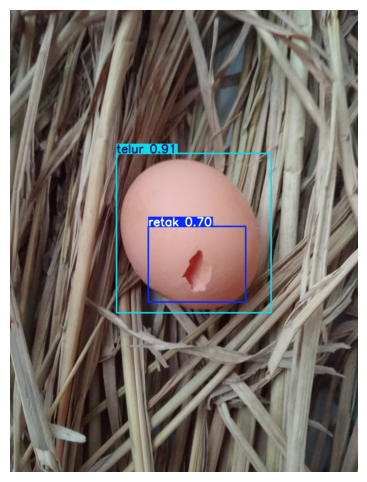

In [40]:
# tampilkan gambar
import glob, os
import cv2
import matplotlib.pyplot as plt

folders = glob.glob("/content/runs/detect/predict*")
latest_folder = max(folders, key=os.path.getmtime)

images = glob.glob(latest_folder + "/*.jpg") + glob.glob(latest_folder + "/*.png")
img_path = images[0]

print("Menampilkan:", img_path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()
plt.show()

In [41]:
# simpann hasil prediksi ke drive
import shutil, os, glob

# cari folder predict terbaru
folders = glob.glob("/content/runs/detect/predict*")
latest_folder = max(folders, key=os.path.getmtime)

# simpan ke folder Drive yang kamu buka tadi
dst = "/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_prediksi_yolo"

# copy isi folder terbaru ke Drive
shutil.copytree(latest_folder, dst, dirs_exist_ok=True)

print("Folder terbaru:", latest_folder)
print("Berhasil disimpan ke:", dst)
print("Isi Drive sekarang:", os.listdir(dst))

Folder terbaru: /content/runs/detect/predict-6
Berhasil disimpan ke: /content/drive/MyDrive/PUI_DATASET_FINAL/hasil_prediksi_yolo
Isi Drive sekarang: ['baik_454.jpg', 'cukup_002.jpg', 'rusak_059.jpg', 'rusak_042.jpg', 'rusak_174.jpg']


In [42]:
# evaluasi yolo
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/PUI_DATASET_FINAL/hasil_yolo_deteksi_telur_v8/weights/best.pt")

metrics = model.val(
    data="/content/dataset_yolo_telur-2/data.yaml",
    imgsz=512
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 830.7±271.7 MB/s, size: 56.1 KB)
val: Scanning /content/dataset_yolo_telur-2/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.3s/it 6.5s
                   all         30         37      0.963      0.929      0.974      0.687
                 retak          6          7      0.946      0.857      0.953      0.493
                 telur         30         30      0.979          1      0.995      0.881
Speed: 3.4ms preprocess, 200.3ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/detect/val-6
